cuda


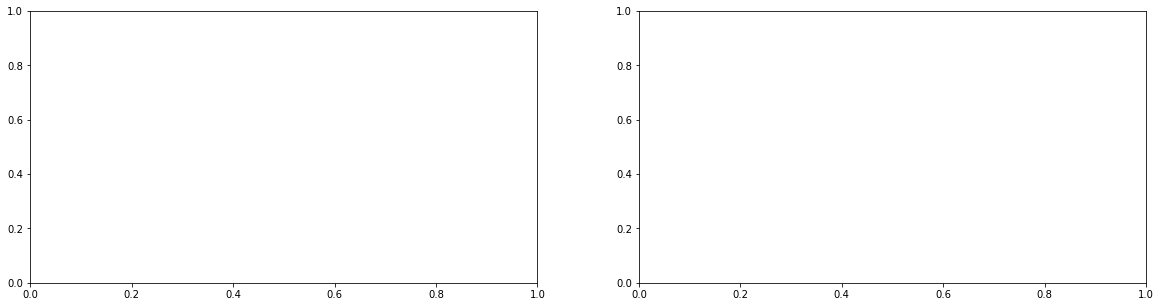

In [2]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

# $P=2^{20}$

768 1 3e-4 2.0 tensor(3.4481) tensor(0.0261)
768 1 3e-4 4.0 tensor(3.3035) tensor(0.0304)
768 1 3e-4 8.0 tensor(3.3074) tensor(0.0281)
768 1 1e-3 2.0 tensor(3.3045) tensor(0.0175)
768 1 1e-3 4.0 tensor(3.1354) tensor(0.0049)
768 1 1e-3 8.0 tensor(3.1447) tensor(0.0207)
768 32 3e-4 32.0 tensor(3.6227) tensor(0.0110)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

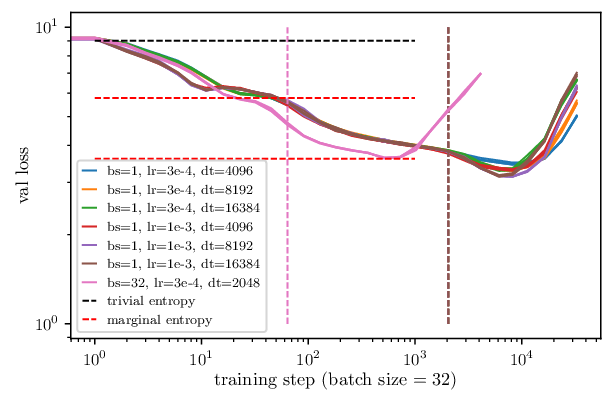

In [8]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in [ '3e-4', '1e-3']:
    for dt in [ 4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


bs = 32
lr = '3e-4'
for dt in [2048]:
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 1 1e-3 2.0 0.1 tensor(3.3045) tensor(0.0175)
768 1 1e-3 4.0 0.1 tensor(3.1354) tensor(0.0049)
768 1 1e-3 8.0 0.1 tensor(3.1447) tensor(0.0207)
768 1 1e-3 2.0 0.01 tensor(3.3380) tensor(0.0288)
768 1 1e-3 4.0 0.01 tensor(3.0879) tensor(0.0254)
768 1 1e-3 8.0 0.01 tensor(3.1165) tensor(0.0245)
768 1 1e-3 16.0 0.01 tensor(nan) tensor(nan)
768 1 3e-3 2.0 0.01 tensor(3.6436) tensor(0.0300)
768 1 3e-3 4.0 0.01 tensor(3.2451) tensor(0.0265)
768 1 3e-3 8.0 0.01 tensor(3.1713) tensor(0.0290)
768 1 3e-3 16.0 0.01 tensor(nan) tensor(nan)
768 1 1e-2 2.0 0.01 tensor(3.3572) tensor(0.0175)
768 1 1e-2 4.0 0.01 tensor(3.1144) tensor(0.0266)
768 1 1e-2 8.0 0.01 tensor(3.1419) tensor(0.0150)
768 1 1e-2 16.0 0.01 tensor(nan) tensor(nan)
768 1 1e-3 2.0 0.0 tensor(3.4998) tensor(0.0200)
768 1 1e-3 4.0 0.0 tensor(3.0875) tensor(0.0146)
768 1 1e-3 8.0 0.0 tensor(3.1319) tensor(0.0393)
768 1 1e-3 16.0 0.0 tensor(nan) tensor(nan)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=1$)')

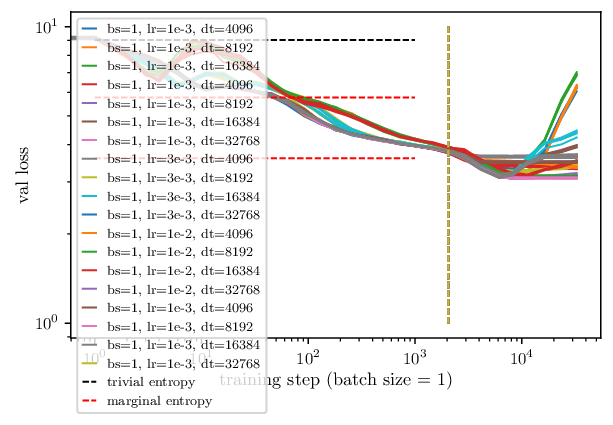

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in ['1e-3']:
    for dt in [ 4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, 0.1, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

path = f'tinystories/trained/T{T}/P{P}/df0.01/'
depth = 12
nh = 12
de = 768
bs = 1
for lr in ['1e-3', '3e-3', '1e-2']:
    for dt in [ 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, 0.01, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


path = f'tinystories/trained/T{T}/P{P}/df0.0/'
depth = 12
nh = 12
de = 768
bs = 1
for lr in ['1e-3']:
    for dt in [ 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])

        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, 0.0, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

wd 0.01 768 1 1e-3 2.0 0.01 tensor(3.3844) tensor(0.0203)
wd 0.01 768 1 1e-3 4.0 0.01 tensor(3.1824) tensor(0.0169)
wd 0.01 768 1 1e-3 8.0 0.01 tensor(3.0645) tensor(0.0226)
wd 0.01 768 1 1e-3 16.0 0.01 tensor(3.0298) tensor(0.0190)
wd 0.01 768 1 1e-3 2.0 0.01 tensor(3.3767) tensor(0.0408)
wd 0.01 768 1 1e-3 4.0 0.01 tensor(3.0823) tensor(0.0241)
wd 0.01 768 1 1e-3 8.0 0.01 tensor(3.1344) tensor(0.0184)
wd 0.01 768 1 1e-3 16.0 0.01 tensor(3.1059) tensor(0.0221)
wd 0.01 768 1 3e-3 2.0 0.01 tensor(3.6463) tensor(0.0223)
wd 0.01 768 1 3e-3 4.0 0.01 tensor(3.1938) tensor(0.0266)
wd 0.01 768 1 3e-3 8.0 0.01 tensor(3.1254) tensor(0.0167)
wd 0.01 768 1 3e-3 16.0 0.01 tensor(3.1284) tensor(0.0170)
wd 0.1 768 1 1e-3 2.0 0.01 tensor(3.4481) tensor(0.0514)
wd 0.1 768 1 1e-3 4.0 0.01 tensor(3.1533) tensor(0.0110)
wd 0.1 768 1 1e-3 8.0 0.01 tensor(3.0566) tensor(0.0208)
wd 0.1 768 1 1e-3 16.0 0.01 tensor(3.0165) tensor(0.0133)
wd 0.1 768 1 3e-3 2.0 0.01 tensor(nan) tensor(nan)
wd 0.1 768 1 3e-3 4.0

Text(0.5, 0, 'training step (batch size $=2$)')

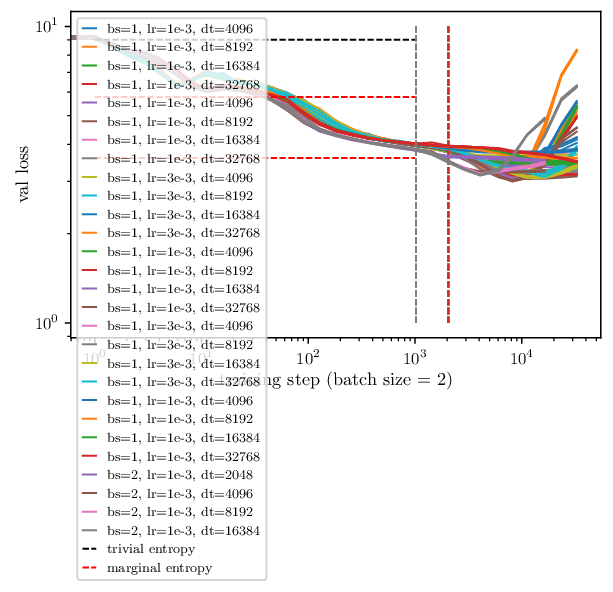

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/l2/'
depth = 12
nh = 12
de = 768

bs = 1
for lr in ['1e-3']:
    for dt in [ 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df0.1_l20.1'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print('wd 0.1', de, bs, lr, dt_ep, 0.1, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

path = f'tinystories/trained/T{T}/P{P}/df0.01/l2/'
depth = 12
nh = 12
de = 768

bs = 1
for lr in ['1e-3', '3e-3']:
    for dt in [ 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df0.01_l20.01'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print('wd 0.01', de, bs, lr, dt_ep, 0.01, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
for lr in ['1e-3', '3e-3']:
    for dt in [ 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df0.01_l20.1'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print('wd 0.1', de, bs, lr, dt_ep, 0.01, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
for lr in ['1e-3']:
    for dt in [ 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df0.01_l21.0'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print('wd 1.0', de, bs, lr, dt_ep, 0.01, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
for lr in ['1e-3']:
    for dt in [ 2048, 4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df0.01_l20.1'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print('wd 0.1', de, bs, lr, dt_ep, 0.01, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
        
ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

wd 0.1 768 2 1e-3 2.0 0.01 tensor(3.5132) tensor(0.0275)
wd 0.1 768 2 1e-3 4.0 0.01 tensor(3.2283) tensor(0.0120)
wd 0.1 768 2 1e-3 8.0 0.01 tensor(3.1742) tensor(0.0162)
wd 0.1 768 2 1e-3 16.0 0.01 tensor(3.1479) tensor(0.0140)
wd 0.1 768 2 1e-3 32.0 0.01 tensor(nan) tensor(nan)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

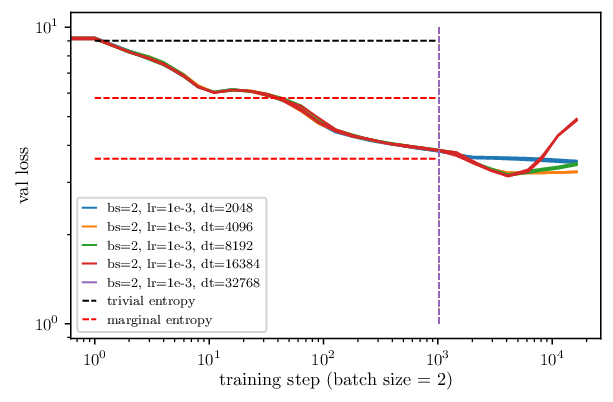

In [6]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/df0.01/l2/'
depth = 12
nh = 12
de = 768

bs = 2
for lr in ['1e-3']:
    for dt in [ 2048, 4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df0.01_l20.1'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print('wd 0.1', de, bs, lr, dt_ep, 0.01, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
        
ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{21}$

768 1 3e-4 2.0 tensor(2.8888) tensor(0.0099)
768 1 3e-4 4.0 tensor(2.7038) tensor(0.0127)
768 1 3e-4 8.0 tensor(2.7250) tensor(0.0183)
768 1 1e-3 2.0 tensor(2.7193) tensor(0.0247)
768 1 1e-3 4.0 tensor(2.5949) tensor(0.0094)
768 1 1e-3 8.0 tensor(2.6080) tensor(0.0186)
768 32 3e-4 16.0 tensor(3.0841) tensor(0.0067)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

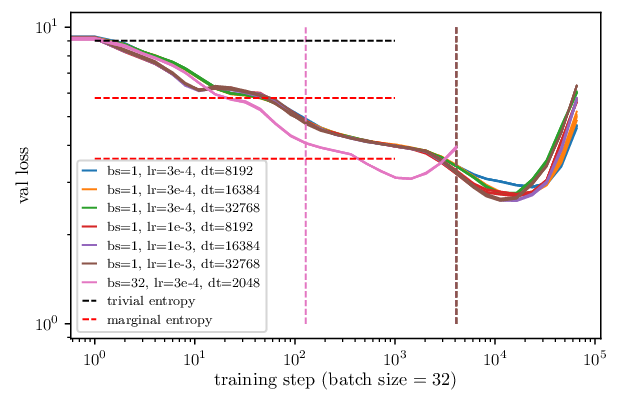

In [7]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 2097152
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in [ '3e-4', '1e-3']:
    for dt in [ 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


bs = 32
lr = '3e-4'
for dt in [2048]:
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{21}$ : bs=1, lr=1e-3, dt=32768 (4 ep)

# TODO higher learning rate at bs=1 anfd try bs=2

# $P=2^{22}$

768 1 3e-4 2.0 tensor(2.3973) tensor(0.0185)
768 1 3e-4 4.0 tensor(2.2786) tensor(0.0156)
768 1 3e-4 8.0 tensor(2.3245) tensor(0.0224)
768 1 1e-3 2.0 tensor(2.2974) tensor(0.0072)
768 1 1e-3 4.0 tensor(2.2250) tensor(0.0164)
768 1 1e-3 8.0 tensor(2.2495) tensor(0.0076)
768 1 3e-3 2.0 tensor(2.4318) tensor(0.0210)
768 1 3e-3 4.0 tensor(2.3193) tensor(0.0302)
768 1 3e-3 8.0 tensor(2.3459) tensor(0.0155)
768 2 1e-3 2.0 tensor(2.3309) tensor(0.0132)
768 2 1e-3 4.0 tensor(2.2493) tensor(0.0125)
768 2 1e-3 8.0 tensor(2.2934) tensor(0.0168)
768 32 3e-4 8.0 tensor(2.5854) tensor(0.0144)
wd 0.1 768 1 1e-3 2.0 0.01 tensor(2.3343) tensor(0.0069)
wd 0.1 768 1 1e-3 4.0 0.01 tensor(2.1382) tensor(0.0080)
wd 0.1 768 1 1e-3 8.0 0.01 tensor(2.0390) tensor(0.0110)
wd 0.1 768 1 1e-3 16.0 0.01 tensor(2.1082) tensor(0.0126)
wd 0.1 768 1 1e-3 2.0 0.1 tensor(2.2812) tensor(0.0105)
wd 0.1 768 1 1e-3 4.0 0.1 tensor(2.1777) tensor(0.0124)
wd 0.1 768 1 1e-3 8.0 0.1 tensor(2.0874) tensor(0.0101)
wd 0.1 768 1 1e-3

Text(0.5, 0, 'training step (batch size $=1$)')

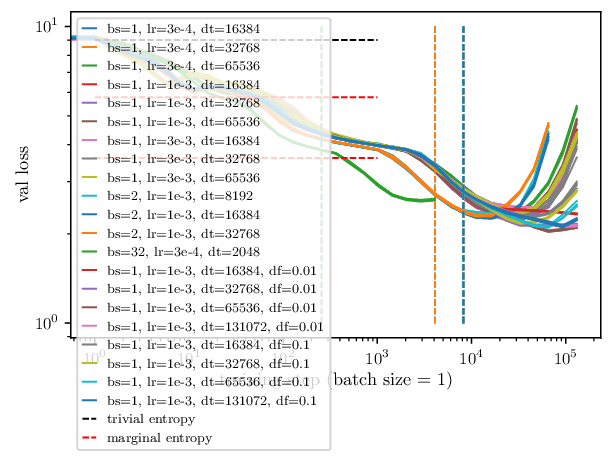

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in [ '3e-4', '1e-3', '3e-3']:
    for dt in [ 16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


bs = 2
for lr in [ '1e-3']:
    for dt in [ 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '3e-4'
for dt in [2048]:
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

path = f'tinystories/trained/T{T}/P{P}/l2/'
depth = 12
nh = 12
de = 768
bs = 1
for lr in ['1e-3']:
    for df in ['0.01', '0.1']:
        for dt in [ 16384, 32768, 65536, 131072]:
            dt_ep = dt//(P/(bs*T))
            i += 1
            prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df{df}_l20.1'
            collection = collect( path, prefix)
            mean_loss = []
            for entry in collection:

                results = torch.load(path+prefix+entry['ending'])
                dynamics = results['dynamics']
                ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
                mean_loss.append(results['best']['loss'])
            #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
            print('wd 0.1', de, bs, lr, dt_ep, df, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
            ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
            custom_lines.append(Line2D([0], [0], color=f'C{i}'))
            custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, df={df}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{22}$ : bs=1, lr=1e-3, dt=32768 (4 ep)

# $P=2^{23}$

768 1 1e-4 2.0 tensor(2.1812) tensor(0.0219)
768 1 1e-4 4.0 tensor(2.0619) tensor(0.0124)
768 1 1e-4 8.0 tensor(2.0725) tensor(0.0176)
768 1 3e-4 2.0 tensor(2.0564) tensor(0.0172)
768 1 3e-4 4.0 tensor(1.9600) tensor(0.0148)
768 1 3e-4 8.0 tensor(2.0150) tensor(0.0147)
768 1 1e-3 2.0 tensor(2.0186) tensor(0.0189)
768 1 1e-3 4.0 tensor(1.9459) tensor(0.0076)
768 1 1e-3 8.0 tensor(1.9880) tensor(0.0054)
768 1 3e-3 2.0 tensor(2.1120) tensor(0.0274)
768 1 3e-3 4.0 tensor(2.0119) tensor(0.0062)
768 1 3e-3 8.0 tensor(2.0043) tensor(0.0285)
768 2 1e-4 2.0 tensor(2.2256) tensor(0.0071)
768 2 1e-4 4.0 tensor(2.1311) tensor(0.0057)
768 2 1e-4 8.0 tensor(2.0947) tensor(0.0065)
768 2 3e-4 2.0 tensor(2.0505) tensor(0.0177)
768 2 3e-4 4.0 tensor(1.9617) tensor(0.0044)
768 2 3e-4 8.0 tensor(2.0163) tensor(0.0210)
768 2 1e-3 2.0 tensor(2.0282) tensor(0.0072)
768 2 1e-3 4.0 tensor(1.9826) tensor(0.0088)
768 2 1e-3 8.0 tensor(2.0211) tensor(0.0090)
768 4 3e-4 2.0 tensor(2.1016) tensor(0.0228)
768 4 3e-4

Text(0.5, 0, 'training step (batch size $=32$)')

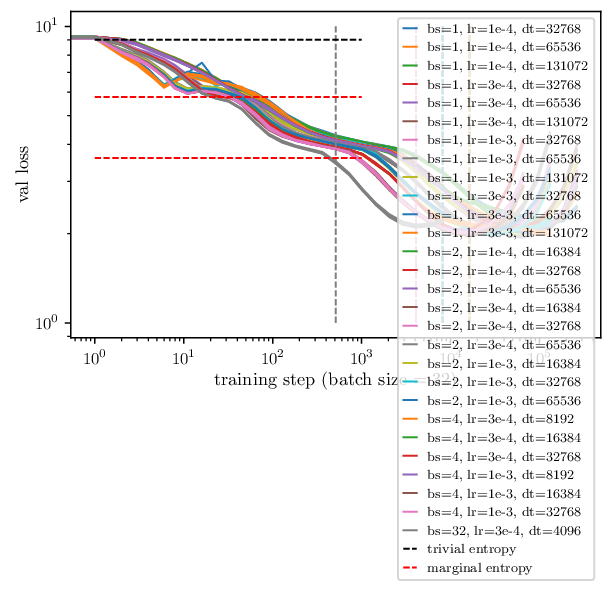

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 8388608
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in ['1e-4', '3e-4', '1e-3', '3e-3']:
    for dt in [ 32768, 65536, 131072]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
    
bs = 2
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
for lr in [ '3e-4', '1e-3']:
    for dt in [8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


bs = 32
lr = '3e-4'
for dt in [4096]:
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{23}$ : bs=1, lr=1e-3, dt=65536 (4 ep)

# $P=2^{24}$

768 1 3e-4 2.0 tensor(1.7924) tensor(0.0094)
768 1 3e-4 4.0 tensor(1.7313) tensor(0.0105)
768 1 3e-4 8.0 tensor(1.7632) tensor(0.0162)
768 2 1e-4 2.0 tensor(1.9032) tensor(0.0059)
768 2 1e-4 4.0 tensor(1.8210) tensor(0.0138)
768 2 1e-4 8.0 tensor(1.8367) tensor(0.0140)
768 2 3e-4 2.0 tensor(1.7945) tensor(0.0145)
768 2 3e-4 4.0 tensor(1.7317) tensor(0.0061)
768 2 3e-4 8.0 tensor(1.7677) tensor(0.0204)
768 2 1e-3 2.0 tensor(1.8052) tensor(0.0167)
768 2 1e-3 4.0 tensor(1.7550) tensor(0.0214)
768 2 1e-3 8.0 tensor(1.7898) tensor(0.0100)
768 4 3e-4 2.0 tensor(1.8117) tensor(0.0018)
768 4 3e-4 4.0 tensor(1.7356) tensor(0.0043)
768 4 3e-4 8.0 tensor(1.7802) tensor(0.0101)
768 4 1e-3 2.0 tensor(1.8153) tensor(0.0090)
768 4 1e-3 4.0 tensor(1.7653) tensor(0.0248)
768 4 1e-3 8.0 tensor(1.7925) tensor(0.0049)
768 8 1e-3 2.0 tensor(1.8089) tensor(0.0022)
768 8 1e-3 4.0 tensor(1.7589) tensor(0.0113)
768 8 1e-3 8.0 tensor(1.7833) tensor(0.0106)
768 32 3e-4 8.0 tensor(1.8378) tensor(0.0053)
1024 1 1e

Text(0.5, 0, 'training step (batch size $=1$)')

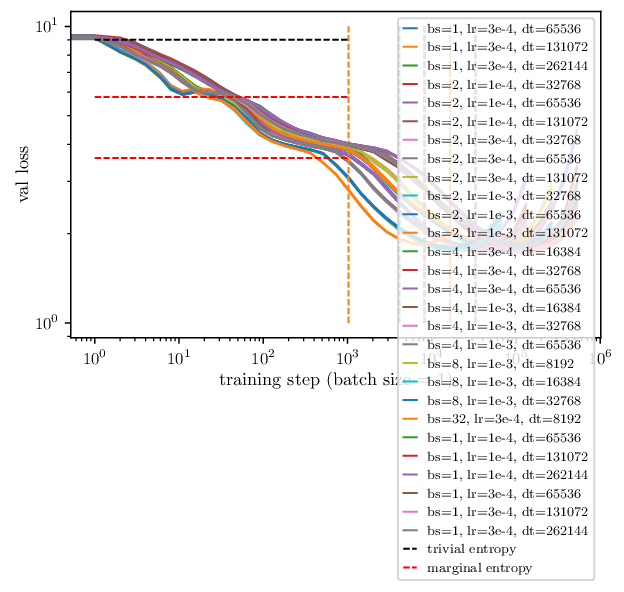

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 16777216
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
lr = '3e-4'
for dt in [ 65536, 131072, 262144]:
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
    
bs = 2
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [32768, 65536, 131072]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
for lr in ['3e-4', '1e-3']:
    for dt in [16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
for lr in ['1e-3']:
    for dt in [8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '3e-4'
for dt in [8192]:
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

depth = 12
nh = 16
de = 1024

bs = 1
for lr in ['1e-4', '3e-4']:
    for dt in [ 65536, 131072, 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 1 3e-4 2.0 tensor(1.7924) tensor(0.0094)
768 1 3e-4 4.0 tensor(1.7313) tensor(0.0105)
768 1 3e-4 8.0 tensor(1.7632) tensor(0.0162)
wd 0.1 768 1 1e-3 2.0 0.01 tensor(1.7294) tensor(0.0087)
wd 0.1 768 1 1e-3 4.0 0.01 tensor(1.6848) tensor(0.0117)
wd 0.1 768 1 1e-3 8.0 0.01 tensor(1.6473) tensor(0.0080)
wd 0.1 768 1 1e-3 16.0 0.01 tensor(1.6280) tensor(0.0086)
wd 0.1 768 1 3e-4 2.0 0.01 tensor(1.8067) tensor(0.0116)
wd 0.1 768 1 3e-4 4.0 0.01 tensor(1.6889) tensor(0.0186)
wd 0.1 768 1 3e-4 8.0 0.01 tensor(1.6208) tensor(0.0050)
wd 0.1 768 1 3e-4 16.0 0.01 tensor(1.6284) tensor(0.0151)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=1$)')

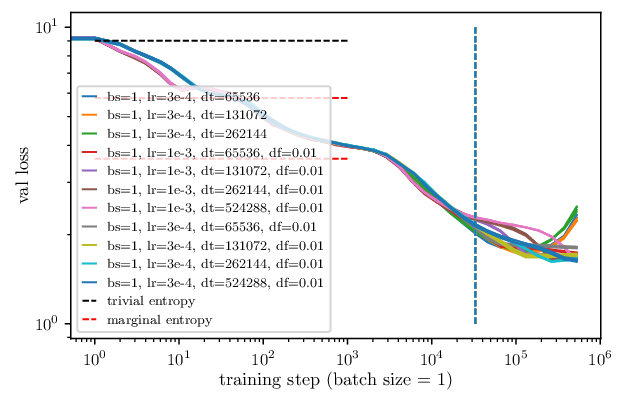

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 16777216
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in [ '3e-4']:
    for dt in [ 65536, 131072, 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


path = f'tinystories/trained/T{T}/P{P}/l2/'
depth = 12
nh = 12
de = 768
bs = 1
for lr in ['1e-3', '3e-4']:
    for df in ['0.01']:
        for dt in [ 65536, 131072, 262144, 524288]:
            dt_ep = dt//(P/(bs*T))
            i += 1
            prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}_df{df}_l20.1'
            collection = collect( path, prefix)
            mean_loss = []
            for entry in collection:

                results = torch.load(path+prefix+entry['ending'])
                dynamics = results['dynamics']
                ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
                mean_loss.append(results['best']['loss'])
            #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
            print('wd 0.1', de, bs, lr, dt_ep, df, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
            ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
            custom_lines.append(Line2D([0], [0], color=f'C{i}'))
            custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, df={df}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{24}$ : bs=1, lr=3e-4, dt=131072 (4 ep)

# TODO: change learning rate at bs=1, try weight decay at higher batch size

# $P=2^{25}$

768 1 3e-4 2.0 tensor(1.5996) tensor(0.0069)
768 1 3e-4 4.0 tensor(1.5544) tensor(0.0089)
768 1 3e-4 8.0 tensor(1.5751) tensor(0.0087)
768 1 1e-3 2.0 tensor(1.6272) tensor(0.0080)
768 1 1e-3 4.0 tensor(1.5897) tensor(0.0123)
768 1 1e-3 8.0 tensor(1.6101) tensor(0.0028)
768 32 3e-4 8.0 tensor(1.6268) tensor(0.0047)
1024 1 3e-4 2.0 tensor(1.6086) tensor(0.0093)
1024 1 3e-4 4.0 tensor(1.5804) tensor(0.0067)
1024 1 3e-4 8.0 tensor(1.5935) tensor(0.0104)
1024 1 1e-3 2.0 tensor(1.6128) tensor(0.0108)
1024 1 1e-3 4.0 tensor(1.5551) tensor(0.0025)
1024 1 1e-3 8.0 tensor(1.5942) tensor(0.0090)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=1$)')

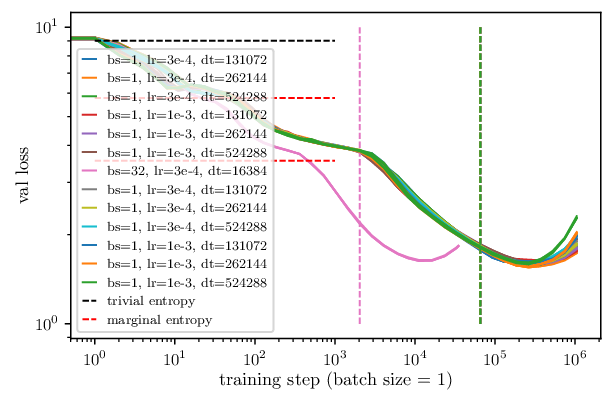

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 33554432
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [ 131072, 262144, 524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
for lr in ['3e-4']:
    for dt in [ 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

depth = 12
nh = 16
de = 1024

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [ 131072, 262144, 524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{25}$ : bs=1, lr=3e-4, dt=262144 (4 ep)

# TODO: try low lr at d_e=768, high lr at d_e=1024

# $P=2^{26}$

768 1 3e-4 2.0 tensor(1.4619) tensor(0.0104)
768 1 3e-4 4.0 tensor(1.4220) tensor(0.0076)
768 1 3e-4 8.0 tensor(1.4228) tensor(0.0098)
768 2 3e-4 2.0 tensor(1.4391) tensor(0.0095)
768 2 3e-4 4.0 tensor(1.3996) tensor(0.0157)
768 2 3e-4 8.0 tensor(1.4225) tensor(0.0062)
1024 1 3e-4 4.0 tensor(1.4274) tensor(0.0102)
1024 1 3e-4 8.0 tensor(1.4607) tensor(0.0056)
1024 2 3e-4 4.0 tensor(1.3971) tensor(0.0159)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

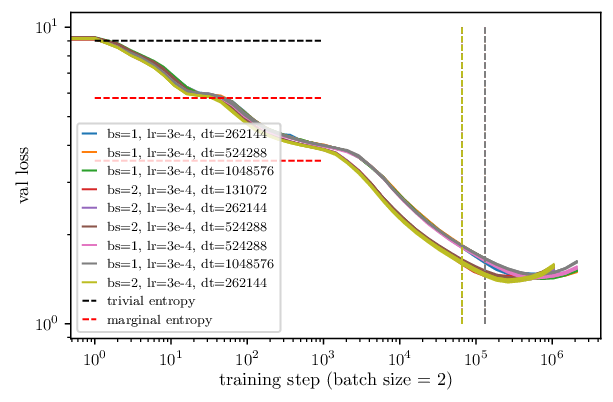

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 67108864
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
for lr in ['3e-4']:
    for dt in [ 262144, 524288, 1048576]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
for lr in ['3e-4']:
    for dt in [ 131072, 262144, 524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

depth = 12
nh = 16
de = 1024

bs = 1
for lr in ['3e-4']:
    for dt in [ 524288, 1048576]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
for lr in ['3e-4']:
    for dt in [ 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{27}$

1024 2 3e-4 4.0 tensor(1.2876) tensor(0.0152)
1024 4 3e-4 4.0 tensor(1.2746) tensor(0.0072)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=4$)')

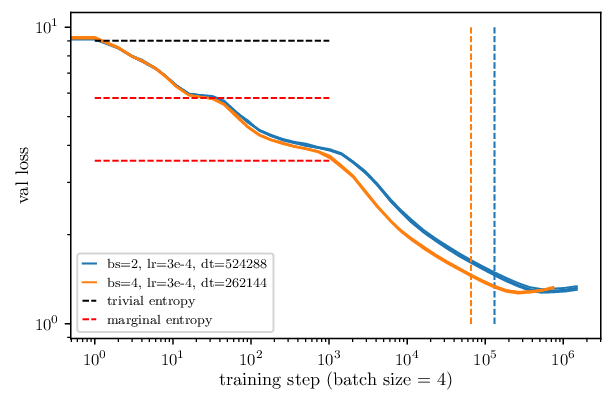

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 134217728
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 16
de = 1024

bs = 2
for lr in ['3e-4']:
    for dt in [ 524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
for lr in ['3e-4']:
    for dt in [ 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{28}$

1024 2 3e-4 4.0 tensor(1.2068) tensor(0.0139)
1024 4 3e-4 4.0 tensor(1.1895) tensor(0.0142)
1024 8 3e-4 4.0 tensor(1.1763) tensor(0.0110)
768 32 3e-4 8.0 tensor(1.2098) tensor(0.0136)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

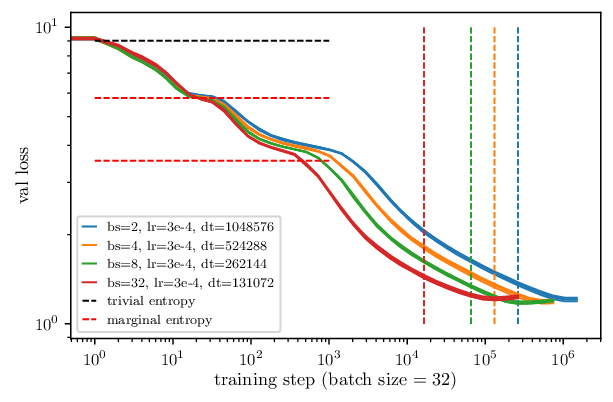

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 268435456
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 16
de = 1024

bs = 2
for lr in ['3e-4']:
    for dt in [ 1048576]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
for lr in ['3e-4']:
    for dt in [ 524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
for lr in ['3e-4']:
    for dt in [ 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

de = 768
nh = 12
bs = 32
for lr in ['3e-4']:
    for dt in [ 131072]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{28}$ : bs=4, lr=3e-4, dt=524288 (4 ep)

# $P\approx2^{29}$

1024 4 3e-4 4.0 tensor(1.1126) tensor(0.0135)
1024 8 3e-4 4.0 tensor(1.1033) tensor(0.0073)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

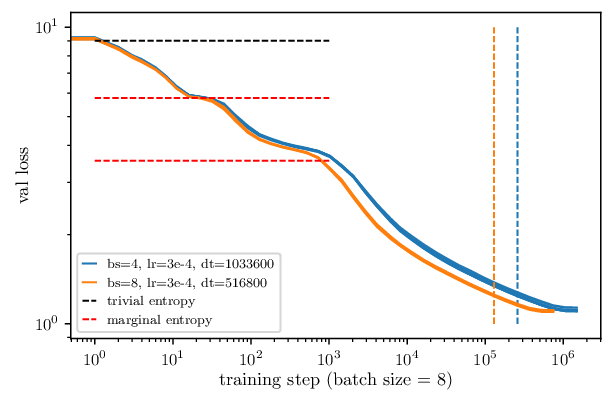

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 16
de = 1024


bs = 4
for lr in ['3e-4']:
    for dt in [ 1033600]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
for lr in ['3e-4']:
    for dt in [ 516800]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# ALLSTARS

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1
T = 256

P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 2
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 16777216
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 4
lr = '3e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)